# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [ ]:
import pandas as pd
import sklearn


### Step 1. Load the data

In [10]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [ ]:
X = df[["Hours_Studied"]]
y = df["Marks"]



,Hours_Studied
0,4.76
1,3.00
2,2.08
3,4.04
4,9.49
...,...
95,3.20
96,9.76
97,4.54
98,9.03


### Step 2.b print the type of each

In [20]:
print(X.dtypes)


Hours_Studied    float64
dtype: object


In [17]:
print(y.dtype)

float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Its numerical so we should use regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [21]:
print("Data matrix (X):", X.shape)
print("Target (y):", y.shape)



Data matrix (X): (100, 1)
Target (y): (100,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [23]:
print("X summary:")
print(X.agg(["min", "max", "median", "mean", "std"]))

print("\ny summary:")
print(y.agg(["min", "max", "median", "mean", "std"]))


X summary:
        Hours_Studied
min          1.050000
max          9.870000
median       5.565000
mean         5.376300
std          2.593013

y summary:
min       20.190000
max       73.260000
median    47.485000
mean      46.360200
std       14.284805
Name: Marks, dtype: float64


### Step 5. Plot the feature vs the target

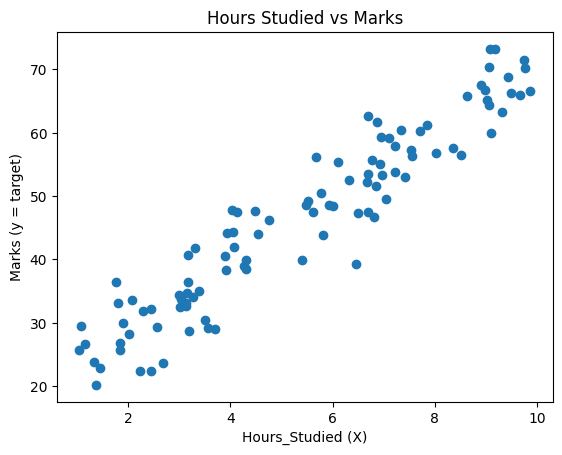

In [26]:
import matplotlib.pyplot as plt

plt.scatter(X["Hours_Studied"], y)
plt.xlabel("Hours_Studied (X)")
plt.ylabel("Marks (y = target)")
plt.title("Hours Studied vs Marks")
plt.show()



### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [ ]:
# There is a strong positive correlation between hours studied and marks,
# Which mean its an increasing relationship, as the hours studied increases, the marks also tend to increase.
# So, students who study more hours their marks tend to increase.

### Step 7. Initialize a `LinearRegression` model

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


### Step 8. Split the dataset into train and test sets

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Step 9.a Train the model on the training set

In [29]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [ ]:
print("Slope:", model.coef_[0])
print("y-intercept:", model.intercept_)


Slope: 5.164438413499557
Y-intercept: 18.538578512317272


### Step 9.c how much marks do we get per 1 hour of study?

In [32]:
# since the slope = 5.16, we can say that we get 5.16 marks for each hour studied


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [33]:
men10 = model.coef_[0]/6
print("Marks increase per 10 minutes studied:", men10)


Marks increase per 10 minutes studied: 0.8607397355832594


### Step 9.e if one doesn't study at all, how much marks do they get?

In [35]:
# he will get the intercept
print("if a student didnt study at all he will get:", model.intercept_, "marks")

if a student didnt study at all he will get: 18.538578512317272 marks


### Step 10. Evaluate the model on the test set

In [ ]:
score = model.score(X_test, y_test)
print("R^2 score:", score)
# The R^2 score is a measure of how well the model explains the variance in the target variable (y) 
# Based on the features (X). A score of 0.95 indicates that the model explains 95% of the variance in the target variable. 
# Which suggests a very good fit to the data.

R^2 score: 0.9258085525213728


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [37]:
sample_X = X_test.head(3)
sample_y = y_test.head(3)

predictions = model.predict(sample_X)

results = sample_X.copy()
results["True_Marks"] = sample_y.values
results["Predicted_Marks"] = predictions
results["Match"] = results["True_Marks"] == results["Predicted_Marks"]

print(results)


    Hours_Studied  True_Marks  Predicted_Marks  Match
83           3.02       32.50        34.135183  False
53           8.90       67.54        64.502080  False
70           6.78       55.70        53.553471  False


In [ ]:
# all the predicted marks are not exactly the same as the true marks
# which is completly normal in a regression problem because the model is trying to find the best fit line
# its almost impossible to predict the exact same marks as the true marks
# but we can see that the predicted marks are close to the true marks which is a good sign

In [ ]:
# in the regression problems its better to use the following code to test whether the predicted marks are close to the true marks or not

results["Difference"] = abs(results["True_Marks"] - results["Predicted_Marks"])
print(results)


    Hours_Studied  True_Marks  Predicted_Marks  Match  Difference
83           3.02       32.50        34.135183  False    1.635183
53           8.90       67.54        64.502080  False    3.037920
70           6.78       55.70        53.553471  False    2.146529


In [ ]:
# if the difference is small, it means that the predicted marks are close to the true marks, which is a good sign.

### Step 12. Plot the data and the regression line

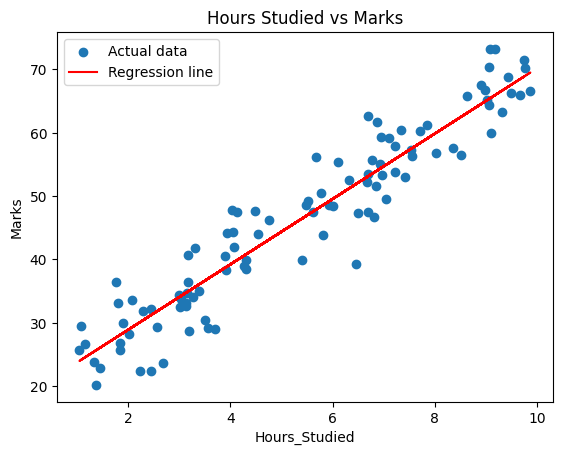

In [39]:
import matplotlib.pyplot as plt

y_pred_line = model.predict(X)

plt.scatter(X["Hours_Studied"], y, label="Actual data")
plt.plot(X["Hours_Studied"], y_pred_line, color="red", label="Regression line")
plt.xlabel("Hours_Studied")
plt.ylabel("Marks")
plt.title("Hours Studied vs Marks")
plt.legend()
plt.show()
